In [2]:
!pip install geopy

   ---------------------------------------- 0.0/125.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/125.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/125.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/125.4 kB ? eta -:--:--
   --------- ----------------------------- 30.7/125.4 kB 187.9 kB/s eta 0:00:01
   ------------ -------------------------- 41.0/125.4 kB 219.4 kB/s eta 0:00:01
   ------------------- ------------------- 61.4/125.4 kB 299.4 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:00:01
   ---------------------------------- --- 112.6/125.4 kB 409.6 kB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HP\AppData\Local\Temp\ipykernel_14312\1494261988.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_bucket = df.groupby("distance_bucket")["logistics_delay"].mean().reset_index()


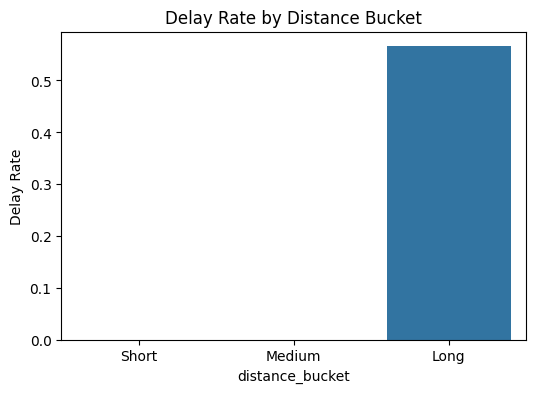

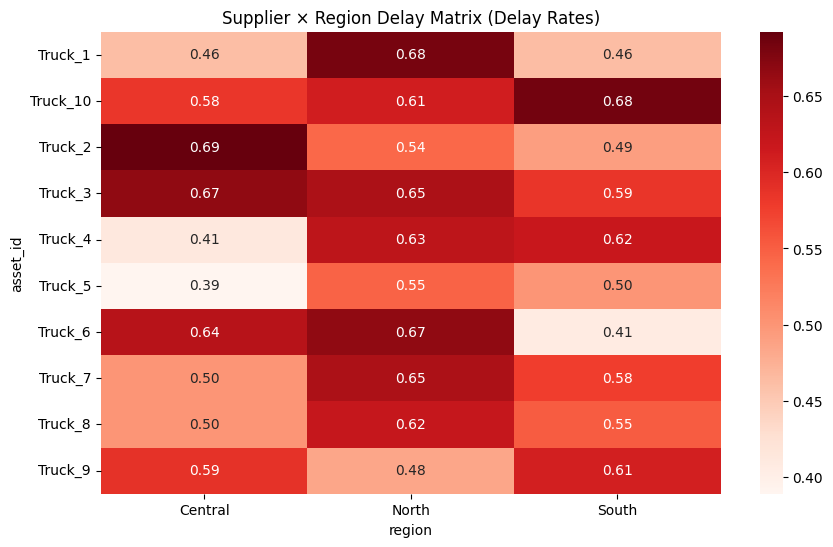

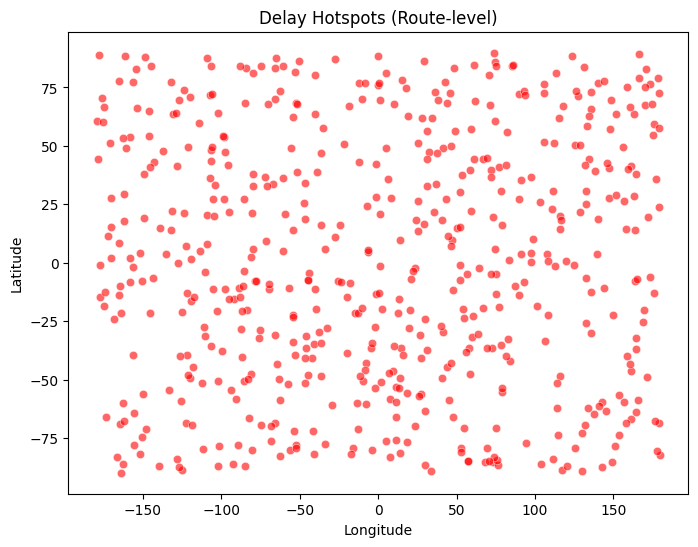

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

# Load dataset
df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")

# ---------- 1. Distance Buckets ----------
# Reference: pick first lat/long per asset as origin, last as destination
route_distances = []
for asset, group in df.groupby("asset_id"):
    start = (group.iloc[0]["latitude"], group.iloc[0]["longitude"])
    end = (group.iloc[-1]["latitude"], group.iloc[-1]["longitude"])
    dist_km = geodesic(start, end).km
    route_distances.append([asset, dist_km])

dist_df = pd.DataFrame(route_distances, columns=["asset_id", "distance_km"])

# Merge back
df = df.merge(dist_df, on="asset_id", how="left")

# Distance buckets
df["distance_bucket"] = pd.cut(df["distance_km"],
                               bins=[0, 300, 800, np.inf],
                               labels=["Short", "Medium", "Long"])

delay_by_bucket = df.groupby("distance_bucket")["logistics_delay"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=delay_by_bucket, x="distance_bucket", y="logistics_delay")
plt.title("Delay Rate by Distance Bucket")
plt.ylabel("Delay Rate")
plt.show()


# ---------- 2. Supplier × Region Matrix ----------
# Define regions based on latitude bands (dummy proxy)
def region_from_lat(lat):
    if lat > 30: return "North"
    elif lat > 0: return "Central"
    else: return "South"

df["region"] = df["latitude"].apply(region_from_lat)

supplier_region = pd.crosstab(df["asset_id"], df["region"],
                              values=df["logistics_delay"], aggfunc="mean").fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(supplier_region, annot=True, cmap="Reds", fmt=".2f")
plt.title("Supplier × Region Delay Matrix (Delay Rates)")
plt.show()


# ---------- 3. Route-Level Hotspots ----------
plt.figure(figsize=(8,6))
hotspot = df[df["logistics_delay"]==1]
sns.scatterplot(data=hotspot, x="longitude", y="latitude", alpha=0.6, color="red")
plt.title("Delay Hotspots (Route-level)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
